In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from helpr.api import CrackEvolutionAnalysis
from helpr.physics.pipe import Pipe
from helpr.physics.crack_initiation import DefectSpecification
from helpr.physics.environment import EnvironmentSpecification, EnvironmentSpecificationRandomLoad
from helpr.physics.material import MaterialSpecification
from helpr.physics.stress_state import InternalAxialHoopStress
from helpr.physics.crack_growth import CrackGrowth, get_design_curve
from helpr.physics.life_assessment import LifeAssessment
from helpr.physics.fracture import calculate_failure_assessment

from helpr.utilities.plots import generate_pipe_life_assessment_plot, plot_random_loading_profiles
from helpr.utilities.postprocessing import calc_pipe_life_criteria, report_single_pipe_life_criteria_results, report_single_cycle_evolution
from helpr.utilities.unit_conversion import convert_psi_to_mpa, convert_in_to_m

from probabilistic.capabilities.uncertainty_definitions import (UniformDistribution, TruncatedNormalDistribution, NormalDistribution,
                                                                TruncatedLognormalDistribution, DeterministicCharacterization,
                                                                TimeSeriesCharacterization)


## **Random Pressure Loading**

### Load user specification input file for random pressure loading

In [3]:
pressure_data = pd.read_csv('./Data/random_loading_demo.csv', index_col=0)

pressure_data['r_ratio'] = pressure_data['Min']/pressure_data['Max']
# Calculate the 10th, 25th, 50th, 75th percentiles for the r_ratio column
percentile_10 = pressure_data['r_ratio'].quantile(0.10)
percentile_25 = pressure_data['r_ratio'].quantile(0.25)
percentile_50 = pressure_data['r_ratio'].quantile(0.50)
percentile_75 = pressure_data['r_ratio'].quantile(0.75)

# Grab samples that are close to the 10th, 25th, 50th, and 75th percentiles
sample_10th_percentile = pressure_data.loc[(pressure_data['r_ratio'] - percentile_10).abs().idxmin()]
sample_25th_percentile = pressure_data.loc[(pressure_data['r_ratio'] - percentile_25).abs().idxmin()]
sample_50th_percentile = pressure_data.loc[(pressure_data['r_ratio'] - percentile_50).abs().idxmin()]
sample_75th_percentile = pressure_data.loc[(pressure_data['r_ratio'] - percentile_75).abs().idxmin()]

print("10th Percentile Value of r_ratio:", percentile_10)
print("Sample Close to 10th Percentile:")
print(sample_10th_percentile)

print("25th Percentile Value of r_ratio:", percentile_25)
print("Sample Close to 25th Percentile:")
print(sample_25th_percentile)

print("50th Percentile Value of r_ratio:", percentile_50)
print("Sample Close to 50th Percentile:")
print(sample_50th_percentile)

print("\n75th Percentile Value of r_ratio:", percentile_75)
print("Sample Close to 75th Percentile:")
print(sample_75th_percentile)

10th Percentile Value of r_ratio: 0.8256739409499357
Sample Close to 10th Percentile:
Min        643.000000
Max        779.000000
r_ratio      0.825417
Name: 48, dtype: float64
25th Percentile Value of r_ratio: 0.8562556204503933
Sample Close to 25th Percentile:
Min        607.000000
Max        709.000000
r_ratio      0.856135
Name: 4, dtype: float64
50th Percentile Value of r_ratio: 0.8934531450577664
Sample Close to 50th Percentile:
Min        696.000000
Max        779.000000
r_ratio      0.893453
Name: 56, dtype: float64

75th Percentile Value of r_ratio: 0.9312762973352033
Sample Close to 75th Percentile:
Min        606.000000
Max        651.000000
r_ratio      0.930876
Name: 150, dtype: float64


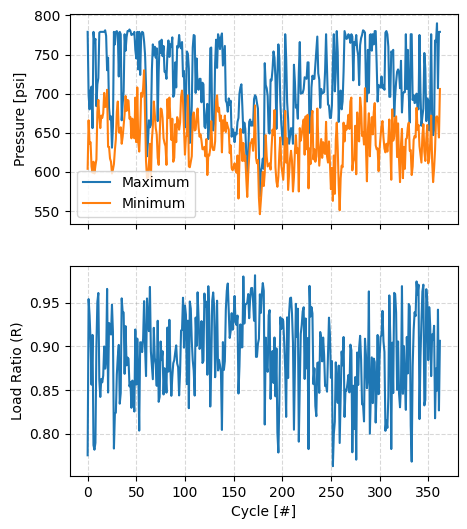

In [4]:
_, _ = plot_random_loading_profiles(minimum_pressure=pressure_data['Min'].to_list(),
                                    maximum_pressure=pressure_data['Max'].to_list(),
                                    pressure_units='psi')

### Create environments based on different static pressure loading conditions as well as the random loading conditions

In [5]:
temperature = 293 # K -> temperature of gas
volume_fraction_h2 = 1 # % mole fraction H2 in natural gas blend

environment_module1 = \
    EnvironmentSpecificationRandomLoad(max_pressure=convert_psi_to_mpa(pressure_data['Max'].values),
                                       min_pressure=convert_psi_to_mpa(pressure_data['Min'].values),
                                       temperature=temperature,
                                       volume_fraction_h2=volume_fraction_h2)

environment_module2 = \
    EnvironmentSpecification(max_pressure=convert_psi_to_mpa(max(pressure_data['Max'].values)),
                             min_pressure=convert_psi_to_mpa(min(pressure_data['Min'].values)),
                             temperature=temperature,
                             volume_fraction_h2=volume_fraction_h2)

environment_module3 = \
    EnvironmentSpecification(max_pressure=convert_psi_to_mpa(sample_10th_percentile['Max']),
                             min_pressure=convert_psi_to_mpa(sample_10th_percentile['Min']),
                             temperature=temperature,
                             volume_fraction_h2=volume_fraction_h2)

environment_module4 = \
    EnvironmentSpecification(max_pressure=convert_psi_to_mpa(sample_25th_percentile['Max']),
                             min_pressure=convert_psi_to_mpa(sample_25th_percentile['Min']),
                             temperature=temperature,
                             volume_fraction_h2=volume_fraction_h2)

environment_module5 = \
    EnvironmentSpecification(max_pressure=convert_psi_to_mpa(sample_50th_percentile['Max']),
                             min_pressure=convert_psi_to_mpa(sample_50th_percentile['Min']),
                             temperature=temperature,
                             volume_fraction_h2=volume_fraction_h2)

environment_module6 = \
    EnvironmentSpecification(max_pressure=convert_psi_to_mpa(sample_75th_percentile['Max']),
                             min_pressure=convert_psi_to_mpa(sample_75th_percentile['Min']),
                             temperature=temperature,
                             volume_fraction_h2=volume_fraction_h2)

environment_module7 = \
    EnvironmentSpecification(max_pressure=convert_psi_to_mpa(np.mean(pressure_data['Max'].values)),
                             min_pressure=convert_psi_to_mpa(np.mean(pressure_data['Min'].values)),
                             temperature=temperature,
                             volume_fraction_h2=volume_fraction_h2)

### Specify Common Analysis Specification

In [6]:
pipe_outer_diameter = convert_in_to_m(36)  # 36 inch outer diameter
wall_thickness = convert_in_to_m(0.406)    # 0.406 inch wall thickness

yield_strength = convert_psi_to_mpa(52_000)  # material yield strength of 52_000 psi
fracture_resistance = 55                     # fracture resistance (toughness) MPa m1/2

flaw_depth = 25                       # flaw 25% through pipe thickness
flaw_length = convert_in_to_m(1.575)  # width of initial crack/flaw, m

surface = 'inside'
k_method = 'anderson'  # Stress intensity factor method used
delta_c_rule = 'proportional'
crack_growth_model = {'model_name': 'code_case_2938'}

cycle_step = 1         # how many cycles in every numerical step
max_cycles = math.inf  # maximum number of steps

### Function to Emulate Crack Evolution Analysis

In [7]:
def create_pipe_evaluation(env_mod, cycle_step=1):

    pipe_mod = Pipe(outer_diameter=pipe_outer_diameter,
                   wall_thickness=wall_thickness)
    
    material_mod = MaterialSpecification(yield_strength=yield_strength,
                                         fracture_resistance=fracture_resistance)
    
    defect_mod = DefectSpecification(flaw_depth=flaw_depth,
                                     flaw_length=flaw_length,
                                     surface=surface)

    stress_mod = InternalAxialHoopStress(pipe=pipe_mod,
                                         environment=env_mod,
                                         material=material_mod,
                                         defect=defect_mod,
                                         stress_intensity_method=k_method)

    crack_grow_mod = CrackGrowth(environment=env_mod,
                                 growth_model_specification=crack_growth_model)

    pipe_eval = LifeAssessment(pipe_specification=pipe_mod,
                               stress_state=stress_mod,
                               crack_growth=crack_grow_mod,
                               delta_c_rule=delta_c_rule)

    load_cycling = pipe_eval.calc_life_assessment(max_cycles=max_cycles,
                                                  cycle_step=cycle_step)

    calculate_failure_assessment({'fracture_resistance': [fracture_resistance],
                                  'yield_strength': [yield_strength]},
                                 [load_cycling],
                                 [stress_mod],
                                 'simple')

    life_criteria = calc_pipe_life_criteria(cycle_results=load_cycling,
                                            pipe=pipe_mod,
                                            material=material_mod)

    return load_cycling, life_criteria

### Crack Evolution Analyses for Environments Specified

In [8]:
load_cycling1, life_criteria1 = create_pipe_evaluation(environment_module1)

/Users/bbschro/Development/helpr_external/src/helpr/physics/stress_state.py:521: UserWarning: Inner Radius / wall thickness exceeds bounds 5 <= R_i/t <= 20, R_i/t = 43.33497536945812, violating Anderson solution limits.
  wr.warn('Inner Radius / wall thickness exceeds bounds ' +


In [9]:
load_cycling2, life_criteria2 = create_pipe_evaluation(environment_module2)

In [10]:
load_cycling3, life_criteria3 = create_pipe_evaluation(environment_module3)

In [11]:
load_cycling4, life_criteria4 = create_pipe_evaluation(environment_module4)

In [12]:
load_cycling5, life_criteria5 = create_pipe_evaluation(environment_module5)

In [13]:
# evolve in terms of a/t to speed up evaluation due to high cycle count
load_cycling6, life_criteria6 = create_pipe_evaluation(environment_module6, cycle_step=None)

In [14]:
load_cycling7, life_criteria7 = create_pipe_evaluation(environment_module7)

In [15]:
specific_life_criteria_result1 = report_single_pipe_life_criteria_results(life_criteria1, pipe_index=0)
specific_load_cycling1 = report_single_cycle_evolution(load_cycling1, pipe_index=0)

specific_life_criteria_result2 = report_single_pipe_life_criteria_results(life_criteria2, pipe_index=0)
specific_load_cycling2 = report_single_cycle_evolution(load_cycling2, pipe_index=0)

specific_life_criteria_result3 = report_single_pipe_life_criteria_results(life_criteria3, pipe_index=0)
specific_load_cycling3 = report_single_cycle_evolution(load_cycling3, pipe_index=0)

specific_life_criteria_result4 = report_single_pipe_life_criteria_results(life_criteria4, pipe_index=0)
specific_load_cycling4 = report_single_cycle_evolution(load_cycling4, pipe_index=0)

specific_life_criteria_result5 = report_single_pipe_life_criteria_results(life_criteria5, pipe_index=0)
specific_load_cycling5 = report_single_cycle_evolution(load_cycling5, pipe_index=0)

specific_life_criteria_result6 = report_single_pipe_life_criteria_results(life_criteria6, pipe_index=0)
specific_load_cycling6 = report_single_cycle_evolution(load_cycling6, pipe_index=0)

              Cycles to a(crit)  Cycles to 25% a(crit)  Cycles to 1/2 Nc  \
Total cycles      202408.474162               1.000000     101204.237081   
a/t                    0.390636               0.097659          0.273613   

              Cycles to FAD line  
Total cycles        181905.00000  
a/t                      0.32682  
              Cycles to a(crit)  Cycles to 25% a(crit)  Cycles to 1/2 Nc  \
Total cycles        2341.533508               1.000000       1170.766754   
a/t                    0.347769               0.086942          0.271827   

              Cycles to FAD line  
Total cycles         2184.737678  
a/t                     0.322840  
              Cycles to a(crit)  Cycles to 25% a(crit)  Cycles to 1/2 Nc  \
Total cycles       57321.937063               1.000000      28660.968532   
a/t                    0.351048               0.087762          0.271996   

              Cycles to FAD line  
Total cycles        54065.251420  
a/t                     0.327264 

### Plots Comparing Impact of Different Pressure Loading Assumptions

/var/folders/m7/xj3t74md7k32bgn0f0bvz3mr002lyh/T/ipykernel_24616/2688859834.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(specific_life_criteria_result1['Cycles to a(crit)'][0],
/var/folders/m7/xj3t74md7k32bgn0f0bvz3mr002lyh/T/ipykernel_24616/2688859834.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  specific_life_criteria_result1['Cycles to a(crit)'][1], 'k*')
/var/folders/m7/xj3t74md7k32bgn0f0bvz3mr002lyh/T/ipykernel_24616/2688859834.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with

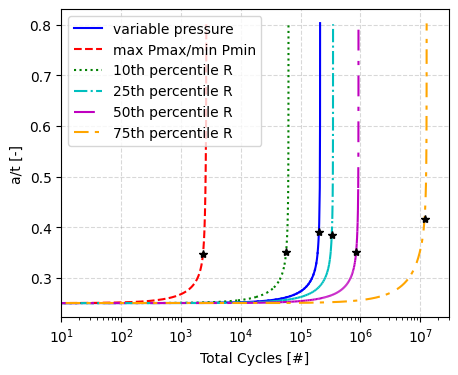

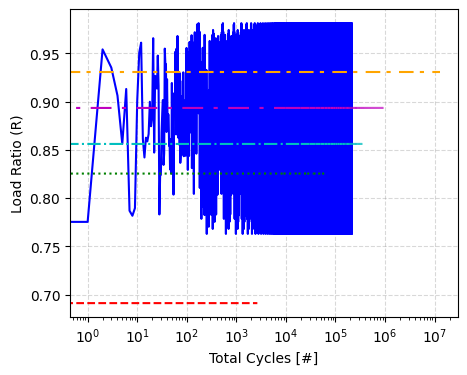

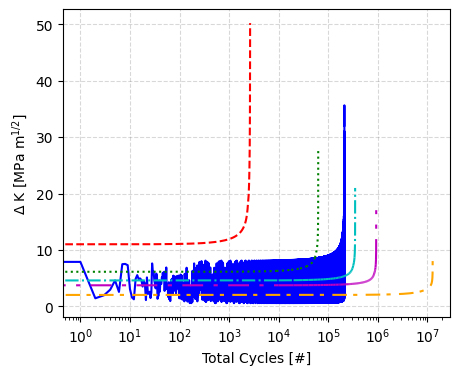

In [16]:
plt.figure(figsize=(5, 4))

plt.plot(specific_load_cycling1['Total cycles'], specific_load_cycling1['a/t'],  'b-', label='variable pressure')
plt.plot(specific_life_criteria_result1['Cycles to a(crit)'][0],
         specific_life_criteria_result1['Cycles to a(crit)'][1], 'k*')

plt.plot(specific_load_cycling2['Total cycles'], specific_load_cycling2['a/t'],  'r--', label='max Pmax/min Pmin')
plt.plot(specific_life_criteria_result2['Cycles to a(crit)'][0],
         specific_life_criteria_result2['Cycles to a(crit)'][1], 'k*')

plt.plot(specific_load_cycling3['Total cycles'], specific_load_cycling3['a/t'],  'g:', label='10th percentile R')
plt.plot(specific_life_criteria_result3['Cycles to a(crit)'][0],
         specific_life_criteria_result3['Cycles to a(crit)'][1], 'k*')

plt.plot(specific_load_cycling4['Total cycles'], specific_load_cycling4['a/t'],  'c-.', label='25th percentile R')
plt.plot(specific_life_criteria_result4['Cycles to a(crit)'][0],
         specific_life_criteria_result4['Cycles to a(crit)'][1], 'k*')

plt.plot(specific_load_cycling5['Total cycles'], specific_load_cycling5['a/t'],  color='m',
         linestyle='-', dashes=[10, 5, 2, 5], label='50th percentile R')
plt.plot(specific_life_criteria_result5['Cycles to a(crit)'][0],
         specific_life_criteria_result5['Cycles to a(crit)'][1], 'k*')

plt.plot(specific_load_cycling6['Total cycles'], specific_load_cycling6['a/t'],  color='orange',
         linestyle='-', dashes=[7, 3, 2, 4], label='75th percentile R')
plt.plot(specific_life_criteria_result6['Cycles to a(crit)'][0],
         specific_life_criteria_result6['Cycles to a(crit)'][1], 'k*')

plt.grid(color='gray', linestyle='--', alpha=0.3)
plt.legend(loc=0)
plt.xlabel('Total Cycles [#]')
plt.ylabel('a/t [-]')
plt.locator_params(axis='x', nbins=6)
plt.xscale('log')
plt.xlim(1E1, 3E7)


plt.figure(figsize=(5, 4))

plt.plot(specific_load_cycling1['Total cycles'],
         specific_load_cycling1['R ratio'],  'b-')
plt.plot(specific_load_cycling2['Total cycles'],
         specific_load_cycling2['R ratio'],  'r--')
plt.plot(specific_load_cycling3['Total cycles'],
         specific_load_cycling3['R ratio'],  'g:')
plt.plot(specific_load_cycling4['Total cycles'],
         specific_load_cycling4['R ratio'],  'c-.')
plt.plot(specific_load_cycling5['Total cycles'],
         specific_load_cycling5['R ratio'],
         color='m', linestyle='-', dashes=[10, 5, 2, 5])
plt.plot(specific_load_cycling6['Total cycles'],
         specific_load_cycling6['R ratio'],
         color='orange', linestyle='-', dashes=[7, 3, 2, 4])

plt.grid(color='gray', linestyle='--', alpha=0.3)
plt.xlabel('Total Cycles [#]')
plt.ylabel('Load Ratio (R)')
plt.xscale('log')


plt.figure(figsize=(5, 4))

plt.plot(specific_load_cycling1['Total cycles'],
         specific_load_cycling1['Kmax (MPa m^1/2)'] - specific_load_cycling1['Kmin (MPa m^1/2)'],  'b-')
plt.plot(specific_load_cycling2['Total cycles'],
         specific_load_cycling2['Kmax (MPa m^1/2)'] - specific_load_cycling2['Kmin (MPa m^1/2)'],  'r--')
plt.plot(specific_load_cycling3['Total cycles'],
         specific_load_cycling3['Kmax (MPa m^1/2)'] - specific_load_cycling3['Kmin (MPa m^1/2)'],  'g:')
plt.plot(specific_load_cycling4['Total cycles'],
         specific_load_cycling4['Kmax (MPa m^1/2)'] - specific_load_cycling4['Kmin (MPa m^1/2)'],  'c-.')
plt.plot(specific_load_cycling5['Total cycles'],
         specific_load_cycling5['Kmax (MPa m^1/2)'] - specific_load_cycling5['Kmin (MPa m^1/2)'],
         color='m', linestyle='-', dashes=[10, 5, 2, 5])
plt.plot(specific_load_cycling6['Total cycles'],
         specific_load_cycling6['Kmax (MPa m^1/2)'] - specific_load_cycling6['Kmin (MPa m^1/2)'],
         color='orange', linestyle='-', dashes=[7, 3, 2, 4])

plt.grid(color='gray', linestyle='--', alpha=0.3)
plt.xlabel('Total Cycles [#]')
plt.ylabel('$\Delta$ K [MPa m$^{1/2}$]')
plt.xscale('log');

/var/folders/m7/xj3t74md7k32bgn0f0bvz3mr002lyh/T/ipykernel_24616/2885443421.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(specific_life_criteria_result1['Cycles to a(crit)'][0],
/var/folders/m7/xj3t74md7k32bgn0f0bvz3mr002lyh/T/ipykernel_24616/2885443421.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  specific_life_criteria_result1['Cycles to a(crit)'][1], 'k*')
/var/folders/m7/xj3t74md7k32bgn0f0bvz3mr002lyh/T/ipykernel_24616/2885443421.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with

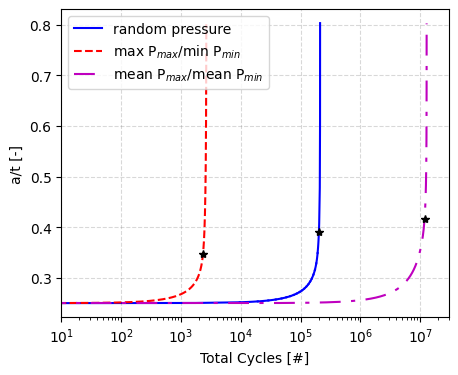

In [17]:
plt.figure(figsize=(5, 4))

plt.plot(specific_load_cycling1['Total cycles'], specific_load_cycling1['a/t'],  'b-', label='random pressure')
plt.plot(specific_life_criteria_result1['Cycles to a(crit)'][0],
         specific_life_criteria_result1['Cycles to a(crit)'][1], 'k*')

plt.plot(specific_load_cycling2['Total cycles'], specific_load_cycling2['a/t'],  'r--', label='max P$_{max}$/min P$_{min}$')
plt.plot(specific_life_criteria_result2['Cycles to a(crit)'][0],
         specific_life_criteria_result2['Cycles to a(crit)'][1], 'k*')

plt.plot(specific_load_cycling6['Total cycles'], specific_load_cycling6['a/t'],  color='m',
         linestyle='-', dashes=[10, 5, 2, 5], label='mean P$_{max}$/mean P$_{min}$')
plt.plot(specific_life_criteria_result6['Cycles to a(crit)'][0],
         specific_life_criteria_result6['Cycles to a(crit)'][1], 'k*')


plt.grid(color='gray', linestyle='--', alpha=0.3)
plt.legend(loc=0)
plt.xlabel('Total Cycles [#]')
plt.ylabel('a/t [-]')
plt.locator_params(axis='x', nbins=6)
plt.xscale('log')
plt.xlim(1E1, 3E7);

### Ensuring That Loaded Random Pressure Data Was Utilized

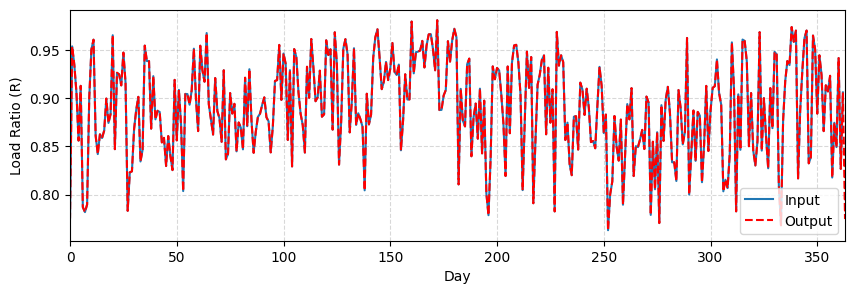

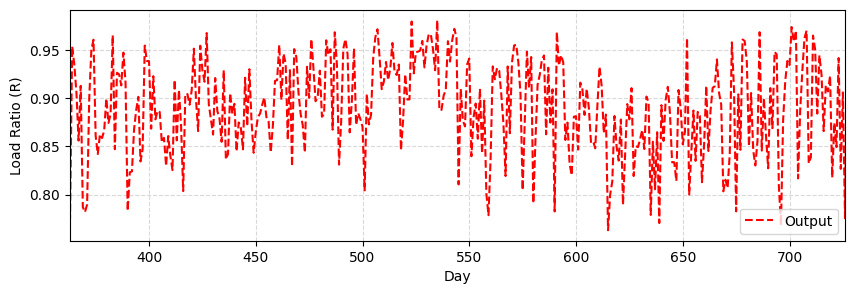

In [18]:
plt.figure(figsize=(10, 3))
plt.plot(pressure_data['r_ratio'], label='Input')

plt.plot(specific_load_cycling1['Total cycles']-1,
         specific_load_cycling1['R ratio'],
         'r--', label='Output')

plt.xlabel('Day')
plt.ylabel('Load Ratio (R)')
plt.grid(color='gray', linestyle='--', alpha=0.3)
plt.legend(loc=0)
plt.xlim(0, 363)

plt.figure(figsize=(10, 3))
plt.plot(specific_load_cycling1['Total cycles']-1,
         specific_load_cycling1['R ratio'],
         'r--', label='Output')

plt.xlabel('Day')
plt.ylabel('Load Ratio (R)')
plt.grid(color='gray', linestyle='--', alpha=0.3)
plt.legend(loc=0)
plt.xlim(363, 363*2);

### Passing Random Pressure Loading Profile Through API Interface for Deterministic Analysis

In [19]:
analysis_det = CrackEvolutionAnalysis(outer_diameter=DeterministicCharacterization(name='outer_diameter', value=pipe_outer_diameter),
                                      wall_thickness=DeterministicCharacterization(name='wall_thickness', value=wall_thickness),
                                      flaw_depth=DeterministicCharacterization(name='flaw_depth', value=flaw_depth),
                                      max_pressure=TimeSeriesCharacterization(name='max_pressure', value=convert_psi_to_mpa(pressure_data['Max'].values)),
                                      min_pressure=TimeSeriesCharacterization(name='min_pressure', value=convert_psi_to_mpa(pressure_data['Min'].values)),
                                      temperature=DeterministicCharacterization(name='temperature', value=temperature),
                                      volume_fraction_h2=DeterministicCharacterization(name='volume_fraction_h2', value=volume_fraction_h2),
                                      yield_strength=DeterministicCharacterization(name='yield_strength', value=yield_strength),
                                      fracture_resistance=DeterministicCharacterization(name='fracture_resistance', value=fracture_resistance),
                                      flaw_length=DeterministicCharacterization(name='flaw_length', value=flaw_length),
                                      stress_intensity_method=k_method,
                                      surface=surface,
                                      cycle_step=cycle_step,
                                      max_cycles=max_cycles)

analysis_det.perform_study()

/Users/bbschro/Development/helpr_external/src/helpr/physics/stress_state.py:521: UserWarning: Inner Radius / wall thickness exceeds bounds 5 <= R_i/t <= 20, R_i/t = 43.33497536945812, violating Anderson solution limits.
  wr.warn('Inner Radius / wall thickness exceeds bounds ' +


In [20]:
# Only print intermediate variables for first values in random pressure loading
analysis_det.nominal_intermediate_variables

{'r_ratio': np.float64(0.7753530166880616),
 'fugacity_ratio': np.float64(0.16223362994308482),
 '%SMYS': np.float64(66.417203486169),
 'a (m)': 0.0025781000000000003,
 'a/2c': 0.06444444444444446,
 't/R': 0.023076048652949873}

              Cycles to a(crit)  Cycles to 25% a(crit)  Cycles to 1/2 Nc  \
Total cycles      202408.474162               1.000000     101204.237081   
a/t                    0.390636               0.097659          0.273613   

              Cycles to FAD line  
Total cycles        181905.00000  
a/t                      0.32682  


/Users/bbschro/Development/helpr_external/src/helpr/api.py:960: UserWarning: Extraction of FAD intersection QoI when using user specified random loading profile may be incorrect due to its stochastic nature.
  warnings.warn(


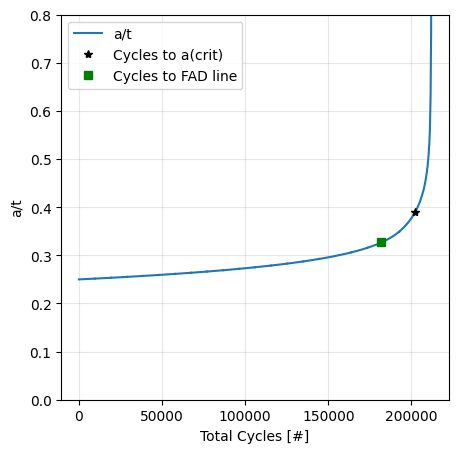

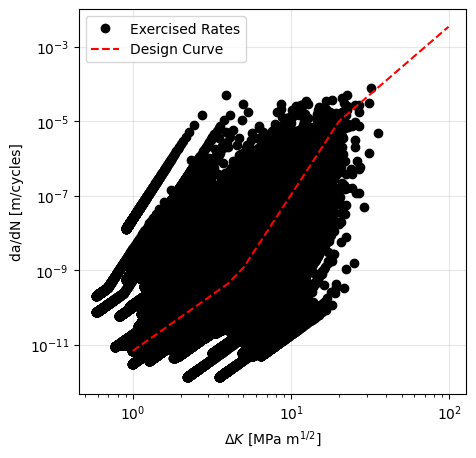

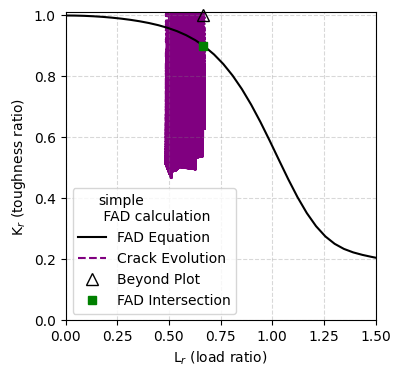

In [21]:
analysis_det.postprocess_single_crack_results()
_, _ = analysis_det.get_design_curve_plot()
_, _ = analysis_det.assemble_failure_assessment_diagram()

In [22]:
pipe_outer_diameter = DeterministicCharacterization(name='outer_diameter',
                                                    value=convert_in_to_m(36))  # pipe outer diameter, m
wall_thickness = DeterministicCharacterization(name='wall_thickness',
                                               value=convert_in_to_m(0.406))  # pipe wall thickness, m

yield_strength = DeterministicCharacterization(name='yield_strength',
                                               value=convert_psi_to_mpa(52_000))  # material yield strength, psi
fracture_resistance = DeterministicCharacterization(name='fracture_resistance',
                                                    value=55)  # fracture resistance (toughness), MPa m1/2

max_pressure = TimeSeriesCharacterization(name='max_pressure',
                                          value=convert_psi_to_mpa(pressure_data['Max'].values))
min_pressure = TimeSeriesCharacterization(name='min_pressure',
                                          value=convert_psi_to_mpa(pressure_data['Min'].values))

temperature = UniformDistribution(name='temperature',
                                  uncertainty_type='aleatory',
                                  nominal_value=293,
                                  upper_bound=300,
                                  lower_bound=285)  # gas blend temperature variation, K
volume_fraction_h2 = UniformDistribution(name='volume_fraction_h2',
                                         uncertainty_type='aleatory',
                                         nominal_value=0.1,
                                         upper_bound=0.2,
                                         lower_bound=0)  # % volume fraction H2 in natural gas blend, fraction

flaw_depth = TruncatedLognormalDistribution(name='flaw_depth',
                                            uncertainty_type='aleatory',
                                            nominal_value=25,
                                            mu=3.2,
                                            sigma=.17,
                                            upper_bound=80,
                                            lower_bound=0.001) # initial flaw depth, % wall thickness
flaw_length = DeterministicCharacterization(name='flaw_length',
                                            value=convert_in_to_m(1.575))  # length of initial crack/flaw, m

sample_size = 10
sample_type = 'lhs'

In [23]:
analysis_prob = CrackEvolutionAnalysis(outer_diameter=pipe_outer_diameter,
                                  wall_thickness=wall_thickness,
                                  flaw_depth=flaw_depth,
                                  max_pressure=max_pressure,
                                  min_pressure=min_pressure,
                                  temperature=temperature,
                                  volume_fraction_h2=volume_fraction_h2,
                                  yield_strength=yield_strength,
                                  fracture_resistance=fracture_resistance,
                                  flaw_length=flaw_length,
                                  aleatory_samples=sample_size,
                                  sample_type=sample_type,
                                  stress_intensity_method=k_method,
                                  surface=surface,
                                  cycle_step=cycle_step,
                                  max_cycles=max_cycles)
analysis_prob.perform_study()     

/Users/bbschro/Development/helpr_external/src/helpr/physics/stress_state.py:521: UserWarning: Inner Radius / wall thickness exceeds bounds 5 <= R_i/t <= 20, R_i/t = 43.33497536945812, violating Anderson solution limits.
  wr.warn('Inner Radius / wall thickness exceeds bounds ' +


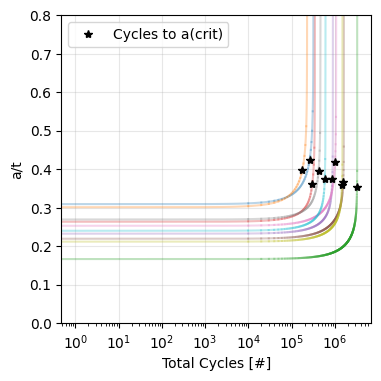

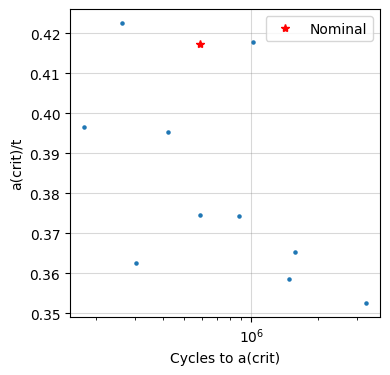

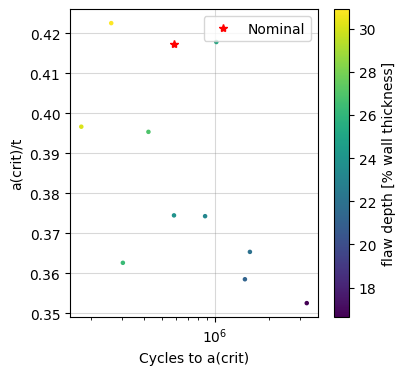

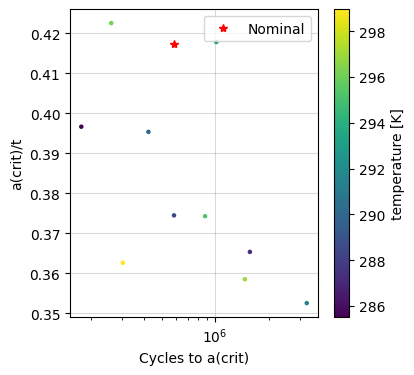

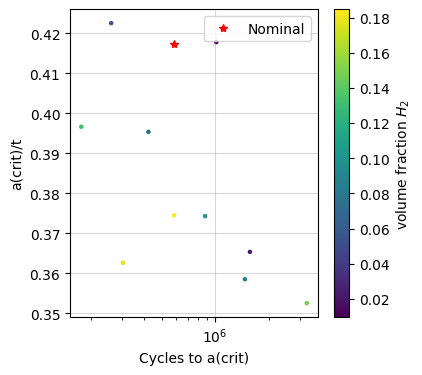

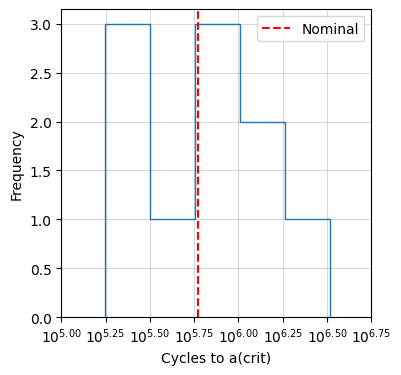

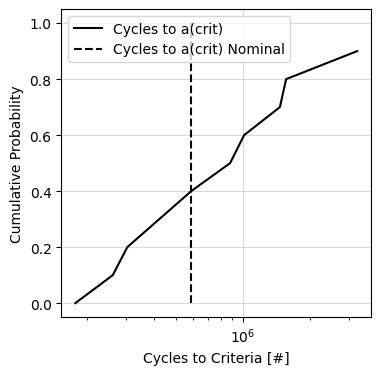

In [24]:
analysis_prob.generate_probabilistic_results_plots(plotted_variable=['Cycles to a(crit)'])

/Users/bbschro/Development/helpr_external/src/helpr/api.py:960: UserWarning: Extraction of FAD intersection QoI when using user specified random loading profile may be incorrect due to its stochastic nature.
  warnings.warn(


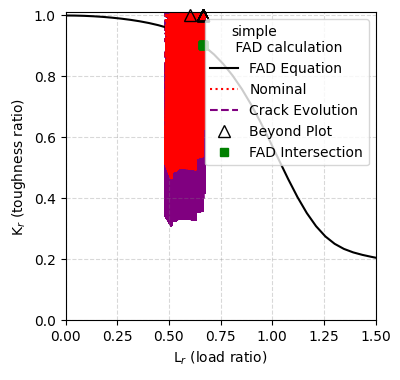

In [25]:
_, _ = analysis_prob.assemble_failure_assessment_diagram()

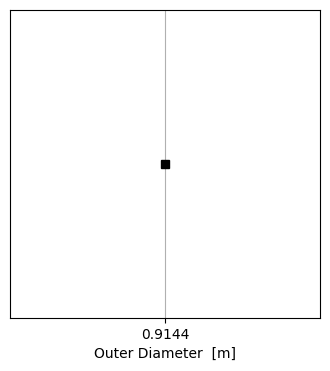

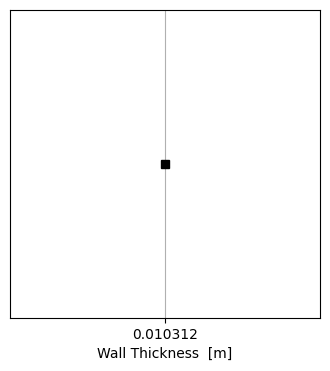

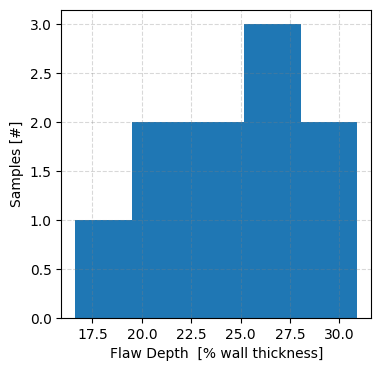

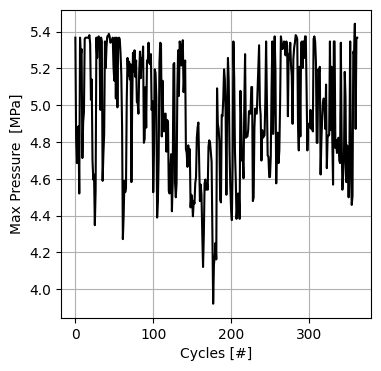

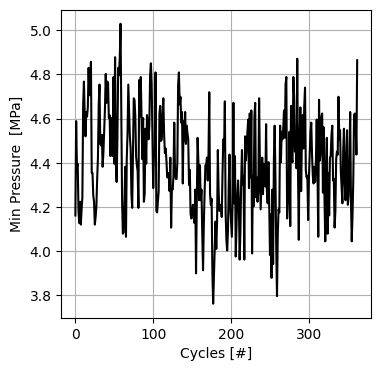

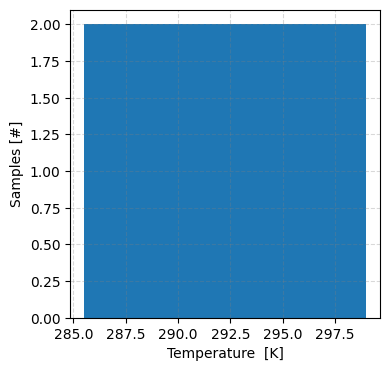

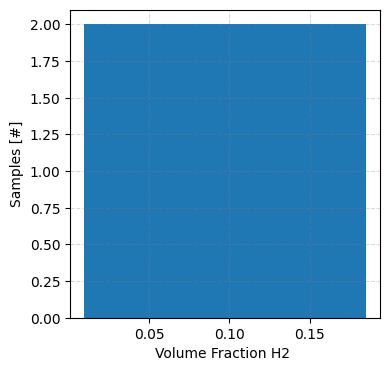

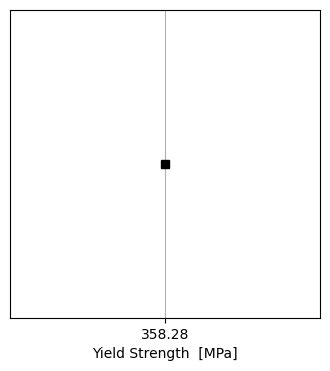

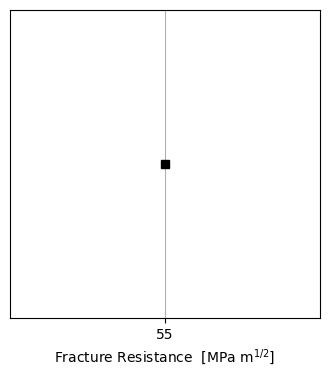

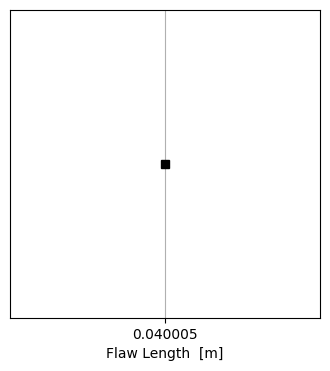

In [26]:
_ = analysis_prob.generate_input_parameter_plots()

#### Checking that Random Loading and Residual Stress Capabilities Can Work At the Same Time

In [27]:
pipe_outer_diameter = convert_in_to_m(36)  # 36 inch outer diameter
wall_thickness = convert_in_to_m(0.406)    # 0.406 inch wall thickness

yield_strength = convert_psi_to_mpa(52_000)  # material yield strength of 52_000 psi
fracture_resistance = 55                     # fracture resistance (toughness) MPa m1/2

flaw_depth = 25                       # flaw 25% through pipe thickness
flaw_length = convert_in_to_m(1.575)  # width of initial crack/flaw, m

temperature = 293 # K -> temperature of gas
volume_fraction_h2 = 1 # % mole fraction H2 in natural gas blend

surface = 'inside'
k_method = 'anderson'  # Stress intensity factor method used
delta_c_rule = 'proportional'
crack_growth_model = {'model_name': 'code_case_2938'}

cycle_step = 1         # how many cycles in every numerical step
max_cycles = math.inf  # maximum number of steps

k_res_explicit_det = DeterministicCharacterization(name='residual_stress_intensity_factor', value=12.)

analysis_det_w_resid = CrackEvolutionAnalysis(outer_diameter=DeterministicCharacterization(name='outer_diameter',
                                                                                           value=pipe_outer_diameter),
                                      wall_thickness=DeterministicCharacterization(name='wall_thickness',
                                                                                   value=wall_thickness),
                                      flaw_depth=DeterministicCharacterization(name='flaw_depth',
                                                                               value=flaw_depth),
                                      max_pressure=TimeSeriesCharacterization(name='max_pressure',
                                                                              value=convert_psi_to_mpa(pressure_data['Max'].values)),
                                      min_pressure=TimeSeriesCharacterization(name='min_pressure',
                                                                              value=convert_psi_to_mpa(pressure_data['Min'].values)),
                                      temperature=DeterministicCharacterization(name='temperature',
                                                                                value=temperature),
                                      volume_fraction_h2=DeterministicCharacterization(name='volume_fraction_h2',
                                                                                       value=volume_fraction_h2),
                                      yield_strength=DeterministicCharacterization(name='yield_strength',
                                                                                   value=yield_strength),
                                      fracture_resistance=DeterministicCharacterization(name='fracture_resistance',
                                                                                        value=fracture_resistance),
                                      flaw_length=DeterministicCharacterization(name='flaw_length',
                                                                                value=flaw_length),
                                      stress_intensity_method=k_method,
                                      surface=surface,
                                      cycle_step=cycle_step,
                                      max_cycles=max_cycles,
                                      residual_stress_intensity_factor=k_res_explicit_det)

analysis_det_w_resid.perform_study()

/Users/bbschro/Development/helpr_external/src/helpr/physics/stress_state.py:521: UserWarning: Inner Radius / wall thickness exceeds bounds 5 <= R_i/t <= 20, R_i/t = 43.33497536945812, violating Anderson solution limits.
  wr.warn('Inner Radius / wall thickness exceeds bounds ' +


              Cycles to a(crit)  Cycles to 25% a(crit)  Cycles to 1/2 Nc  \
Total cycles      126753.937315               1.000000      63376.968658   
a/t                    0.310651               0.077663          0.268675   

              Cycles to FAD line  
Total cycles        50863.895232  
a/t                     0.264147  


/Users/bbschro/Development/helpr_external/src/helpr/api.py:960: UserWarning: Extraction of FAD intersection QoI when using user specified random loading profile may be incorrect due to its stochastic nature.
  warnings.warn(


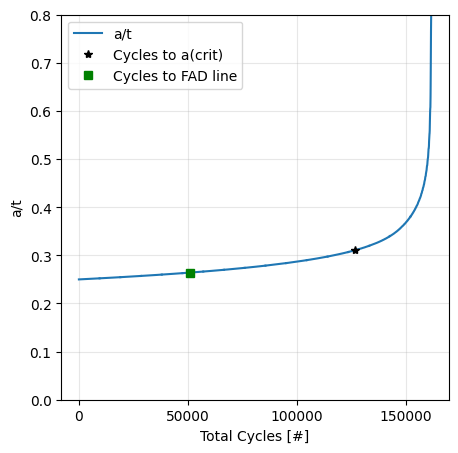

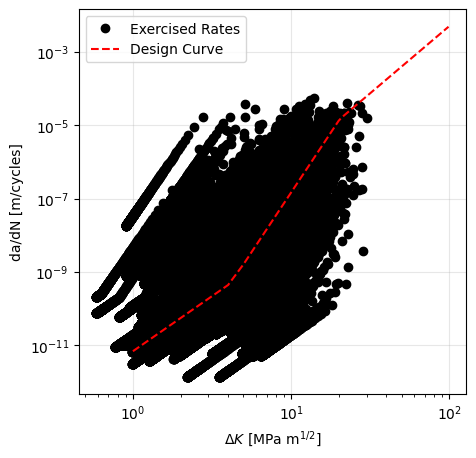

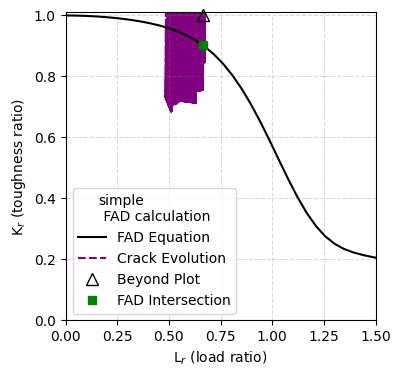

In [28]:
analysis_det_w_resid.postprocess_single_crack_results()
_, _ = analysis_det_w_resid.get_design_curve_plot()
_, _ = analysis_det_w_resid.assemble_failure_assessment_diagram()

In [29]:
pipe_outer_diameter = DeterministicCharacterization(name='outer_diameter',
                                                    value=convert_in_to_m(36))  # pipe outer diameter, m
wall_thickness = DeterministicCharacterization(name='wall_thickness',
                                               value=convert_in_to_m(0.406))  # pipe wall thickness, m

yield_strength = DeterministicCharacterization(name='yield_strength',
                                               value=convert_psi_to_mpa(52_000))  # material yield strength, psi
fracture_resistance = DeterministicCharacterization(name='fracture_resistance',
                                                    value=55)  # fracture resistance (toughness), MPa m1/2

max_pressure = TimeSeriesCharacterization(name='max_pressure',
                                          value=convert_psi_to_mpa(pressure_data['Max'].values))
min_pressure = TimeSeriesCharacterization(name='min_pressure',
                                          value=convert_psi_to_mpa(pressure_data['Min'].values))

temperature = UniformDistribution(name='temperature',
                                  uncertainty_type='aleatory',
                                  nominal_value=293,
                                  upper_bound=300,
                                  lower_bound=285)  # gas blend temperature variation, K
volume_fraction_h2 = UniformDistribution(name='volume_fraction_h2',
                                         uncertainty_type='aleatory',
                                         nominal_value=0.1,
                                         upper_bound=0.2,
                                         lower_bound=0)  # % volume fraction H2 in natural gas blend, fraction

flaw_depth = TruncatedLognormalDistribution(name='flaw_depth',
                                            uncertainty_type='aleatory',
                                            nominal_value=25,
                                            mu=3.2,
                                            sigma=.17,
                                            upper_bound=80,
                                            lower_bound=0.001) # initial flaw depth, % wall thickness
flaw_length = DeterministicCharacterization(name='flaw_length',
                                            value=convert_in_to_m(1.575))  # length of initial crack/flaw, m

k_res_explicit_prob = NormalDistribution(name='residual_stress_intensity_factor',
                                         uncertainty_type='aleatory',
                                         nominal_value=12.,
                                         mean=12.,
                                         std_deviation=2)

sample_size = 10
sample_type = 'lhs'

analysis_prob_w_resid = CrackEvolutionAnalysis(outer_diameter=pipe_outer_diameter,
                                  wall_thickness=wall_thickness,
                                  flaw_depth=flaw_depth,
                                  max_pressure=max_pressure,
                                  min_pressure=min_pressure,
                                  temperature=temperature,
                                  volume_fraction_h2=volume_fraction_h2,
                                  yield_strength=yield_strength,
                                  fracture_resistance=fracture_resistance,
                                  flaw_length=flaw_length,
                                  aleatory_samples=sample_size,
                                  sample_type=sample_type,
                                  stress_intensity_method=k_method,
                                  surface=surface,
                                  residual_stress_intensity_factor=k_res_explicit_prob,
                                  cycle_step=cycle_step,
                                  max_cycles=max_cycles)
analysis_prob_w_resid.perform_study()

/Users/bbschro/Development/helpr_external/src/helpr/physics/stress_state.py:521: UserWarning: Inner Radius / wall thickness exceeds bounds 5 <= R_i/t <= 20, R_i/t = 43.33497536945812, violating Anderson solution limits.
  wr.warn('Inner Radius / wall thickness exceeds bounds ' +


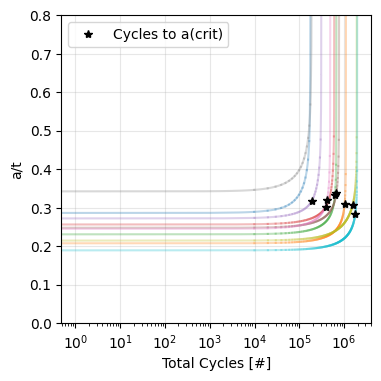

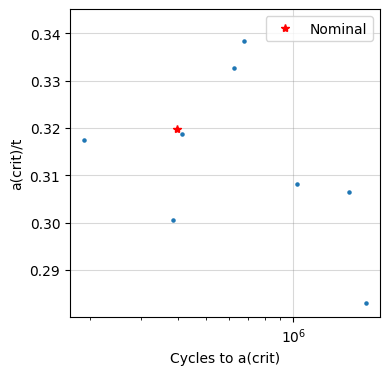

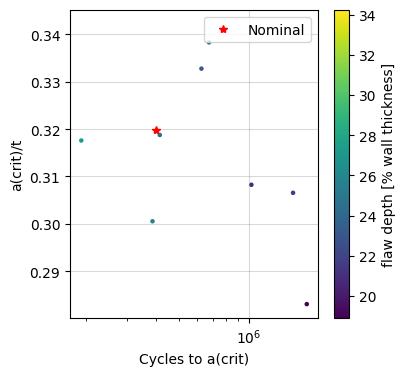

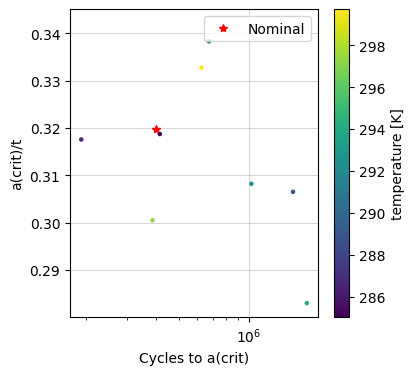

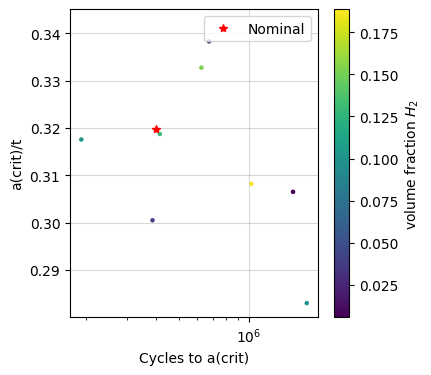

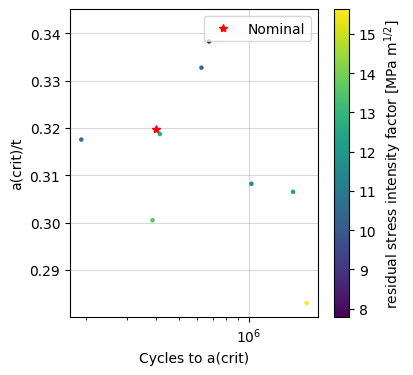

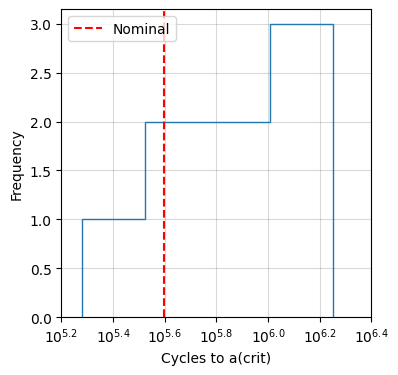

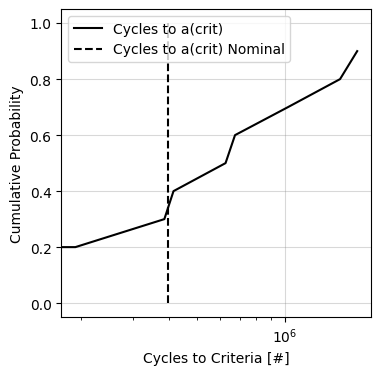

In [30]:
analysis_prob_w_resid.generate_probabilistic_results_plots(plotted_variable=['Cycles to a(crit)'])

/Users/bbschro/Development/helpr_external/src/helpr/api.py:960: UserWarning: Extraction of FAD intersection QoI when using user specified random loading profile may be incorrect due to its stochastic nature.
  warnings.warn(


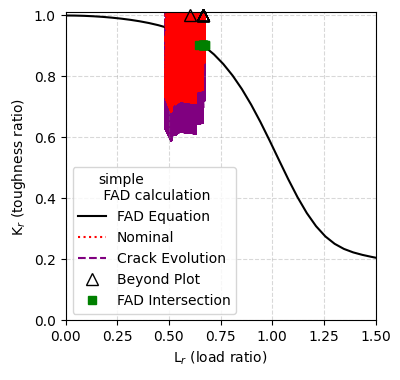

In [31]:
_, _ = analysis_prob_w_resid.assemble_failure_assessment_diagram()

### Testing Capability with Depressurization Spike

In [32]:
temperature = 293 # K -> temperature of gas
volume_fraction_h2 = 1 # % mole fraction H2 in natural gas blend

pipe_outer_diameter = convert_in_to_m(36)  # 36 inch outer diameter
wall_thickness = convert_in_to_m(0.406)    # 0.406 inch wall thickness

yield_strength = convert_psi_to_mpa(52_000)  # material yield strength of 52_000 psi
fracture_resistance = 55                     # fracture resistance (toughness) MPa m1/2

flaw_depth = 25                       # flaw 25% through pipe thickness
flaw_length = convert_in_to_m(1.575)  # width of initial crack/flaw, m

surface = 'inside'
k_method = 'anderson'  # Stress intensity factor method used
delta_c_rule = 'proportional'
crack_growth_model = {'model_name': 'code_case_2938'}

cycle_step = 1         # how many cycles in every numerical step
max_cycles = math.inf  # maximum number of steps


pressure_data_spike = pd.read_csv('./Data/random_loading_demo_spike.csv', index_col=0)

environment_module_spike = \
    EnvironmentSpecificationRandomLoad(max_pressure=convert_psi_to_mpa(pressure_data_spike['Max'].values),
                                       min_pressure=convert_psi_to_mpa(pressure_data_spike['Min'].values),
                                       temperature=temperature,
                                       volume_fraction_h2=volume_fraction_h2)

load_cycling_spike, life_criteria_spike = create_pipe_evaluation(environment_module_spike)

/Users/bbschro/Development/helpr_external/src/helpr/physics/stress_state.py:521: UserWarning: Inner Radius / wall thickness exceeds bounds 5 <= R_i/t <= 20, R_i/t = 43.33497536945812, violating Anderson solution limits.
  wr.warn('Inner Radius / wall thickness exceeds bounds ' +


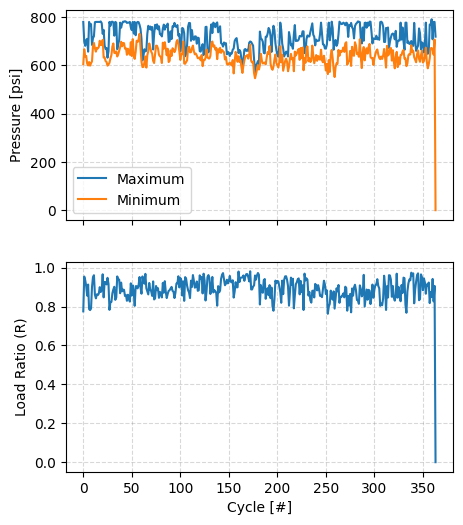

In [33]:
_, _ = plot_random_loading_profiles(minimum_pressure=pressure_data_spike['Min'].to_list(),
                                    maximum_pressure=pressure_data_spike['Max'].to_list(),
                                    pressure_units='psi')

In [34]:
specific_life_criteria_result_spike = report_single_pipe_life_criteria_results(life_criteria_spike, pipe_index=0)
specific_load_cycling_spike = report_single_cycle_evolution(load_cycling_spike, pipe_index=0)

              Cycles to a(crit)  Cycles to 25% a(crit)  Cycles to 1/2 Nc  \
Total cycles       34404.354916               1.000000      17202.177458   
a/t                    0.402765               0.100691          0.284931   

              Cycles to FAD line  
Total cycles        27342.000000  
a/t                     0.326664  


/var/folders/m7/xj3t74md7k32bgn0f0bvz3mr002lyh/T/ipykernel_24616/3863691916.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(specific_life_criteria_result1['Cycles to a(crit)'][0],
/var/folders/m7/xj3t74md7k32bgn0f0bvz3mr002lyh/T/ipykernel_24616/3863691916.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  specific_life_criteria_result1['Cycles to a(crit)'][1], 'k*', zorder=5)
/var/folders/m7/xj3t74md7k32bgn0f0bvz3mr002lyh/T/ipykernel_24616/3863691916.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consi

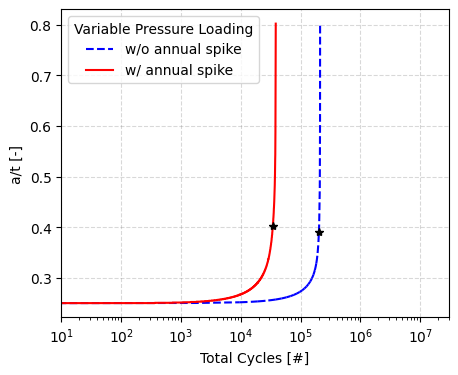

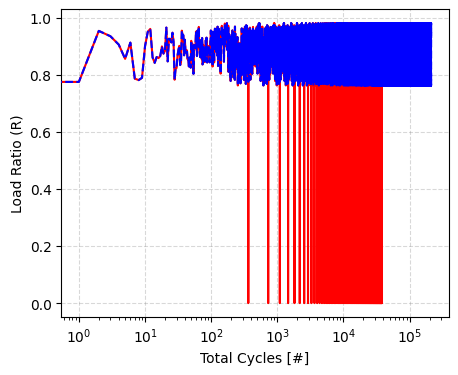

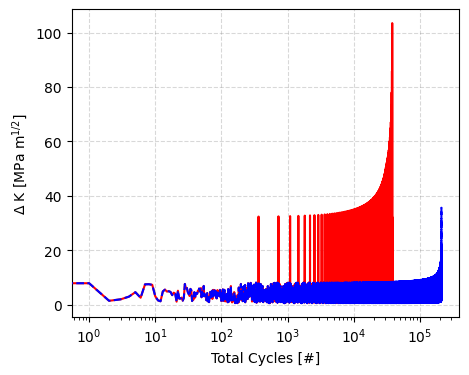

In [35]:
plt.figure(figsize=(5, 4))

plt.plot(specific_load_cycling1['Total cycles'], specific_load_cycling1['a/t'],  'b--', label='w/o annual spike')
plt.plot(specific_life_criteria_result1['Cycles to a(crit)'][0],
         specific_life_criteria_result1['Cycles to a(crit)'][1], 'k*', zorder=5)

plt.plot(specific_load_cycling_spike['Total cycles'], specific_load_cycling_spike['a/t'],  'r-', label='w/ annual spike')
plt.plot(specific_life_criteria_result_spike['Cycles to a(crit)'][0],
         specific_life_criteria_result_spike['Cycles to a(crit)'][1], 'k*')

plt.grid(color='gray', linestyle='--', alpha=0.3)
plt.legend(loc=0, title='Variable Pressure Loading')
plt.xlabel('Total Cycles [#]')
plt.ylabel('a/t [-]')
plt.locator_params(axis='x', nbins=6)
plt.xscale('log')
plt.xlim(1E1, 3E7)


plt.figure(figsize=(5, 4))

plt.plot(specific_load_cycling1['Total cycles'],
         specific_load_cycling1['R ratio'],  'b--', zorder=5)
plt.plot(specific_load_cycling_spike['Total cycles'],
         specific_load_cycling_spike['R ratio'],  'r-')

plt.grid(color='gray', linestyle='--', alpha=0.3)
plt.xlabel('Total Cycles [#]')
plt.ylabel('Load Ratio (R)')
plt.xscale('log')


plt.figure(figsize=(5, 4))

plt.plot(specific_load_cycling1['Total cycles'],
         specific_load_cycling1['Kmax (MPa m^1/2)'] - specific_load_cycling1['Kmin (MPa m^1/2)'],  'b--', zorder=5)
plt.plot(specific_load_cycling_spike['Total cycles'],
         specific_load_cycling_spike['Kmax (MPa m^1/2)'] - specific_load_cycling_spike['Kmin (MPa m^1/2)'],  'r-')

plt.grid(color='gray', linestyle='--', alpha=0.3)
plt.xlabel('Total Cycles [#]')
plt.ylabel('$\Delta$ K [MPa m$^{1/2}$]')
plt.xscale('log');